In [ ]:
import re
import pandas as pd


# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand/two_phase_UG_828588.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str1 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str1)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand 3 segments/two_phase_UG_826748.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str2 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str2)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand 3 segments no ROI/two_phase_UG_829302.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str10 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str10)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand/two_phase_UG_827631.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str4 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str4)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand 3 segments/two_phase_UG_827305.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str5 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str5)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand 3 segments no ROI/two_phase_UG_829303.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str11 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str11)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand/two_phase_UG_828423.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: (-?[\d.]+[eE][+-]?\d+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: (-?[\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str6 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str6)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand 3 segments/two_phase_UG_826821.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: (-?[\d.]+[eE][+-]?\d+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: (-?[\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}
# result_dict = {col: [f"{float(val):.2E}" if val is not None else "None" for val in df[col]] for col in columns}


# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str7 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str7)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand 3 segments no ROI/two_phase_UG_830540.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: (-?[\d.]+[eE][+-]?\d+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: (-?[\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}
# result_dict = {col: [f"{float(val):.2E}" if val is not None else "None" for val in df[col]] for col in columns}


# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str12 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str12)

In [4]:
grouped_by_suffix = {
    'F Objective': {
        'balance_base': [2.65E+09, 2.65E+09, 2.65E+09, 2.65E+09, 2.71E+09, 2.04E+09, 2.04E+09, 2.67E+09, 2.67E+09, 2.67E+09, 2.64E+09],
        'balance_3_segments': [2.71E+09, 2.71E+09, 2.71E+09, 2.71E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09],
        'balance_3_segments_no_ROI': [2.71E+09, 2.71E+09, 2.04E+09, 2.71E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09, 2.04E+09],
        'SB_base': [4.42E+09, 3.60E+09, 3.13E+09, 3.98E+09, 3.91E+09, 3.96E+09, 3.69E+09, 3.61E+09, 3.26E+09, 3.00E+09, 3.09E+09],
        'SB_3_segments': [2.38E+09, 3.13E+09, 3.12E+09, 4.28E+09, 3.67E+09, 2.86E+09, 3.97E+09, 2.33E+09, 3.36E+09, 3.68E+09, 3.77E+09],
        'SB_3_segments_no_ROI': [2.38E+09, 3.13E+09, 3.12E+09, 4.28E+09, 3.67E+09, 2.86E+09, 3.97E+09, 2.33E+09, 3.36E+09, 3.68E+09, 3.77E+09],
        'MP_Base': [8.01E+09, 8.32E+09, 8.17E+09, 8.09E+09, 7.94E+09, 7.93E+09, 8.24E+09, 8.17E+09, 8.09E+09, 8.17E+09, 8.09E+09],
        'MP_3_segments': [3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09],
        'MP_3_segments_no_ROI': [3.89E+09, 3.89E+09, 3.89E+09, 3.99E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09, 3.89E+09],
    },
    'Q Objective': {
        'balance_base': [2.35E+10, 2.38E+10, 2.45E+10, 2.47E+10, 2.52E+10, 2.52E+10, 2.59E+10, 2.68E+10, 2.68E+10, 2.65E+10, 2.61E+10],
        'balance_3_segments': [1.21E+10, 1.21E+10, 1.22E+10, 1.22E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.20E+10, 1.20E+10],
        'balance_3_segments_no_ROI': [1.21E+10, 1.21E+10, 1.19E+10, 1.22E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.19E+10, 1.20E+10, 1.20E+10],  
        'SB_base': [6.58E+10, 4.97E+10, 4.33E+10, 5.53E+10, 4.96E+10, 5.88E+10, 4.94E+10, 3.94E+10, 3.89E+10, 3.69E+10, 4.14E+10],
        'SB_3_segments': [1.32E+10, 1.32E+10, 1.29E+10, 1.39E+10, 1.33E+10, 1.31E+10, 1.45E+10, 1.40E+10, 1.36E+10, 1.37E+10, 1.43E+10],
        'SB_3_segments_no_ROI': [1.32E+10, 1.32E+10, 1.29E+10, 1.39E+10, 1.33E+10, 1.31E+10, 1.45E+10, 1.40E+10, 1.36E+10, 1.37E+10, 1.43E+10],
        'MP_Base': [-3.74E+11, -3.73E+11, -3.73E+11, -3.73E+11, -3.73E+11, -3.73E+11, -3.74E+11, -3.72E+11, -3.71E+11, -3.69E+11, -3.68E+11],
        'MP_3_segments': [-1.52E+10, -1.53E+10, -1.51E+10, -1.51E+10, -1.52E+10, -1.52E+10, -1.51E+10, -1.51E+10, -1.52E+10, -1.52E+10, -1.53E+10],
        'MP_3_segments_no_ROI': [-1.52E+10, -1.53E+10, -1.51E+10, -1.51E+10, -1.52E+10, -1.52E+10, -1.51E+10, -1.51E+10, -1.52E+10, -1.52E+10, -1.53E+10],
    },
    'S Objective': {
        'balance_base': [5.60E+09, 7.06E+09, 8.95E+09, 1.27E+10, 1.59E+10, 1.99E+10, 2.27E+10, 2.54E+10, 3.00E+10, 3.58E+10, 4.23E+10],
        'balance_3_segments': [3.05E+11, 3.16E+11, 3.27E+11, 3.38E+11, 3.50E+11, 3.62E+11, 3.74E+11, 3.86E+11, 3.98E+11, 4.10E+11, 4.23E+11],
        'balance_3_segments_no_ROI': [3.05E+11, 3.16E+11, 3.28E+11, 3.38E+11, 3.50E+11, 3.62E+11, 3.74E+11, 3.86E+11, 3.98E+11, 4.10E+11, 4.23E+11],
        'SB_base': [5.59E+09, 7.06E+09, 8.95E+09, 1.23E+10, 1.53E+10, 1.81E+10, 2.18E+10, 2.54E+10, 3.00E+10, 3.58E+10, 4.23E+10],
        'SB_3_segments': [4.17E+11, 6.12E+11, 3.56E+11, 5.53E+11, 4.70E+11, 3.67E+11, 6.46E+11, 6.15E+11, 6.22E+11, 4.88E+11, 6.61E+11],
        'SB_3_segments_no_ROI': [4.17E+11, 6.12E+11, 3.56E+11, 5.53E+11, 4.70E+11, 3.67E+11, 6.46E+11, 6.15E+11, 6.22E+11, 4.88E+11, 6.61E+11],
        'MP_Base': [3.21E+10, 3.29E+10, 3.49E+10, 3.73E+10, 3.99E+10, 4.25E+10, 4.50E+10, 4.61E+10, 4.70E+10, 4.80E+10, 4.92E+10],
        'MP_3_segments': [1.36E+11, 1.42E+11, 1.47E+11, 1.52E+11, 1.57E+11, 1.62E+11, 1.67E+11, 1.73E+11, 1.78E+11, 1.84E+11, 1.89E+11],
        'MP_3_segments_no_ROI': [1.36E+11, 1.42E+11, 1.47E+11, 1.52E+11, 1.57E+11, 1.62E+11, 1.67E+11, 1.73E+11, 1.78E+11, 1.84E+11, 1.89E+11],
    },
    'I Objective': {
        'balance_base': [7.39E+07, 7.30E+07, 7.51E+07, 7.70E+07, 8.46E+07, 8.64E+07, 8.81E+07, 1.08E+08, 1.12E+08, 1.13E+08, 1.02E+08],
        'balance_3_segments': [7.52E+07, 7.51E+07, 7.51E+07, 7.50E+07, 7.46E+07, 7.49E+07, 7.52E+07, 7.55E+07, 7.57E+07, 7.59E+07, 7.60E+07],
        'balance_3_segments_no_ROI': [7.52E+07, 7.51E+07, 7.43E+07, 7.50E+07, 7.46E+07, 7.49E+07, 7.52E+07, 7.55E+07, 7.57E+07, 7.59E+07, 7.60E+07],
        'SB_base': [1.53E+08, 1.22E+08, 1.33E+08, 1.07E+08, 1.42E+08, 1.27E+08, 1.47E+08, 1.37E+08, 1.07E+08, 1.09E+08, 1.28E+08],
        'SB_3_segments': [9.92E+07, 9.13E+07, 8.83E+07, 9.76E+07, 9.67E+07, 8.26E+07, 1.07E+08, 1.10E+08, 8.89E+07, 1.05E+08, 1.01E+08],
        'SB_3_segments_no_ROI': [9.92E+07, 9.13E+07, 8.83E+07, 9.76E+07, 9.67E+07, 8.26E+07, 1.07E+08, 1.10E+08, 8.89E+07, 1.05E+08, 1.01E+08],
        'MP_Base': [6.81E+08, 7.81E+08, 7.53E+08, 7.86E+08, 7.41E+08, 7.45E+08, 6.63E+08, 8.66E+08, 2.98E+08, 7.58E+08, 6.10E+08],
        'MP_3_segments': [1.86E+08, 2.43E+08, 3.50E+08, 3.53E+08, 2.92E+08, 3.11E+08, 3.42E+08, 3.35E+08, 3.49E+08, 1.81E+08, 1.90E+08],
        'MP_3_segments_no_ROI': [1.86E+08, 2.43E+08, 3.50E+08, 3.53E+08, 2.92E+08, 3.11E+08, 3.42E+08, 3.35E+08, 3.49E+08, 1.81E+08, 1.90E+08],
    },
    'Y Objective': {
        'balance_base': [6.05E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09],
        'balance_3_segments': [5.82E+09, 5.74E+09, 5.82E+09, 5.84E+09, 6.06E+09, 5.83E+09, 5.82E+09, 5.78E+09, 5.82E+09, 6.09E+09, 5.83E+09],
        'balance_3_segments_no_ROI': [5.78E+09, 6.06E+09, 5.80E+09, 6.07E+09, 6.10E+09, 5.77E+09, 6.10E+09, 6.10E+09, 6.10E+09, 5.75E+09, 5.56E+09],
        'SB_base': [6.03E+09, 6.09E+09, 6.06E+09, 6.06E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.10E+09, 6.09E+09, 6.10E+09, 6.08E+09],
        'SB_3_segments': [5.43E+09, 5.91E+09, 6.10E+09, 5.62E+09, 5.95E+09, 6.06E+09, 5.38E+09, 5.63E+09, 5.98E+09, 5.36E+09, 5.34E+09],
        'SB_3_segments_no_ROI': [5.43E+09, 5.91E+09, 6.10E+09, 5.62E+09, 5.95E+09, 6.06E+09, 5.38E+09, 5.63E+09, 5.98E+09, 5.36E+09, 5.34E+09],
        'MP_Base': [1.02E+10, 1.02E+10, 1.02E+10, 1.02E+10, 1.02E+10, 1.02E+10, 1.02E+10, 1.03E+10, 1.03E+10, 1.03E+10, 1.03E+10],
        'MP_3_segments': [5.98E+09, 5.98E+09, 5.89E+09, 5.89E+09, 5.98E+09, 5.98E+09, 5.89E+09, 5.89E+09, 5.89E+09, 5.98E+09, 5.98E+09],
        'MP_3_segments_no_ROI': [5.98E+09, 5.98E+09, 5.89E+09, 5.89E+09, 5.98E+09, 5.98E+09, 5.89E+09, 5.89E+09, 5.89E+09, 5.98E+09, 5.98E+09],
    },
    'L Objective': {
        'balance_base': [9.18E+09, 1.06E+10, 1.00E+10, 1.09E+10, 1.01E+10, 9.89E+09, 1.04E+10, 9.75E+09, 1.05E+10, 1.06E+10, 1.04E+10],
        'balance_3_segments': [9.52E+09, 1.01E+10, 1.01E+10, 1.01E+10, 9.41E+09, 8.49E+09, 9.31E+09, 1.03E+10, 9.97E+09, 9.08E+09, 9.48E+09],
        'balance_3_segments_no_ROI': [9.78E+09, 9.18E+09, 1.03E+10, 9.95E+09, 1.01E+10, 1.04E+10, 9.70E+09, 9.22E+09, 9.98E+09, 9.63E+09, 1.01E+10],
        'SB_base': [9.97E+09, 9.44E+09, 8.99E+09, 9.35E+09, 8.80E+09, 9.79E+09, 9.57E+09, 9.90E+09, 1.03E+10, 1.02E+10, 1.01E+10],
        'SB_3_segments': [8.65E+09, 9.51E+09, 9.36E+09, 9.69E+09, 9.57E+09, 1.03E+10, 7.61E+09, 8.46E+09, 8.61E+09, 9.00E+09, 9.23E+09],
        'SB_3_segments_no_ROI': [8.65E+09, 9.51E+09, 9.36E+09, 9.69E+09, 9.57E+09, 1.03E+10, 7.61E+09, 8.46E+09, 8.61E+09, 9.00E+09, 9.23E+09],
        'MP_Base': [4.00E+09, 4.00E+09, 4.00E+09, 4.00E+09, 4.00E+09, 4.00E+09, 4.01E+09, 4.01E+09, 4.01E+09, 4.01E+09, 4.01E+09],
        'MP_3_segments': [4.10E+09, 4.10E+09, 4.13E+09, 4.13E+09, 4.13E+09, 4.13E+09, 4.17E+09, 4.17E+09, 4.17E+09, 4.17E+09, 4.17E+09],
        'MP_3_segments_no_ROI': [4.10E+09, 4.10E+09, 4.13E+09, 4.13E+09, 4.13E+09, 4.13E+09, 4.17E+09, 4.17E+09, 4.17E+09, 4.17E+09, 4.17E+09],
    },
    'Total Objective': {
        'balance_base': [3.18E+10, 3.36E+10, 3.61E+10, 4.01E+10, 4.39E+10, 4.72E+10, 5.07E+10, 5.49E+10, 5.96E+10, 6.51E+10, 7.12E+10],
        'balance_3_segments': [3.19E+11, 3.31E+11, 3.42E+11, 3.53E+11, 3.64E+11, 3.76E+11, 3.88E+11, 4.00E+11, 4.12E+11, 4.24E+11, 4.37E+11],
        'balance_3_segments_no_ROI': [3.19E+11, 3.31E+11, 3.42E+11, 3.53E+11, 3.64E+11, 3.76E+11, 3.88E+11, 4.00E+11, 4.12E+11, 4.24E+11, 4.37E+11],
        'SB_base': [5.59E+09, 7.06E+09, 8.95E+09, 1.23E+10, 1.53E+10, 1.81E+10, 2.18E+10, 2.54E+10, 3.00E+10, 3.58E+10, 4.23E+10],
        'SB_3_segments': [4.17E+11, 6.12E+11, 3.56E+11, 5.53E+11, 4.70E+11, 3.67E+11, 6.46E+11, 6.15E+11, 6.22E+11, 4.88E+11, 6.61E+11],
        'SB_3_segments_no_ROI': [4.17E+11, 6.12E+11, 3.56E+11, 5.53E+11, 4.70E+11, 3.67E+11, 6.46E+11, 6.15E+11, 6.22E+11, 4.88E+11, 6.61E+11],
        'MP_Base': [-3.28E+11, -3.26E+11, -3.24E+11, -3.21E+11, -3.19E+11, -3.17E+11, -3.14E+11, -3.12E+11, -3.09E+11, -3.07E+11, -3.04E+11],
        'MP_3_segments': [1.31E+11, 1.36E+11, 1.41E+11, 1.46E+11, 1.51E+11, 1.57E+11, 1.62E+11, 1.68E+11, 1.73E+11, 1.79E+11, 1.84E+11],
        'MP_3_segments_no_ROI': [1.31E+11, 1.36E+11, 1.41E+11, 1.46E+11, 1.51E+11, 1.57E+11, 1.62E+11, 1.68E+11, 1.73E+11, 1.79E+11, 1.84E+11],
    },
}


In [5]:
for suffix, models in grouped_by_suffix.items():
    for model_name, values in models.items():
        models[model_name] = [abs(v) for v in values]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume grouped_by_suffix is your grouped dictionary from earlier
markers = ['o', 'o', '^', '^', '*', '*']

for objective_suffix, group_data in grouped_by_suffix.items():
    df = pd.DataFrame(group_data)
    df['Trial'] = range(1, len(df) + 1)

    plt.figure(figsize=(10, 6))
    for col in df.columns.drop('Trial'):
        plt.plot(df['Trial'], df[col], label=col, marker='o')

    plt.xlabel('Trial')
    plt.ylabel('Objective Value')
    plt.title(f'{objective_suffix} Over Trials')
    # plt.legend()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True)
    plt.xticks(df['Trial'])
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    safe_title = re.sub(r'[^a-zA-Z0-9_]', '_', key)
    plt.savefig(f'{objective_suffix}_updated.png', dpi=300, bbox_inches='tight')
    plt.show()  # Or plt.savefig(...) if saving is desired


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import re  # Needed for safe title

# List of markers to cycle through
markers = ['o', '^', '*', 's', 'D', 'P', 'X']
marker_cycle = itertools.cycle(markers)

for objective_suffix, group_data in grouped_by_suffix.items():
    df = pd.DataFrame(group_data)
    df['Trial'] = range(1, len(df) + 1)

    plt.figure(figsize=(10, 6))
    for col in df.columns.drop('Trial'):
        plt.plot(df['Trial'], df[col], label=col, marker=next(marker_cycle))

    plt.xlabel('Trial')
    plt.ylabel('Objective Value')
    plt.title(f'{objective_suffix} Over Trials')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True)
    plt.xticks(df['Trial'])
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    safe_title = re.sub(r'[^a-zA-Z0-9_]', '_', objective_suffix)
    # plt.savefig(f'{safe_title}_updated.png', dpi=300, bbox_inches='tight')
    plt.show()


## Market segment analysis

In [1]:
def extract_segments_with_z_value_1(data):
    """
    Extracts information where Z[vaccine, producer, time, segment] = 1.

    Args:
        data (dict): A dictionary containing the parsed JSON data.

    Returns:
        dict: A dictionary containing the extracted information,
              structured by vaccine and producer.
    """
    extracted_info = {}

    # Assuming 'Z' is a key in the main dictionary and its value is another dictionary
    # that holds vaccine, producer, time, and segment data.
    if 'Z' in data:
        z_data = data['Z']
        for vaccine, producers_data in z_data.items():
            for producer, time_data in producers_data.items():
                for time_str, segments_data in time_data.items():
                    time = int(time_str)
                    if 1 <= time <= 10:
                        for segment_str, value in segments_data.items():
                            segment = int(segment_str)
                            if 1 <= segment <= 3 and value == 1:
                                if vaccine not in extracted_info:
                                    extracted_info[vaccine] = {}
                                if producer not in extracted_info[vaccine]:
                                    extracted_info[vaccine][producer] = []
                                extracted_info[vaccine][producer].append({"Time": time, "Segment": segment})
    return extracted_info



Processing file: results/segment tests/2 segments new cons 8 UG/MVP_DE_results_T_5_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json


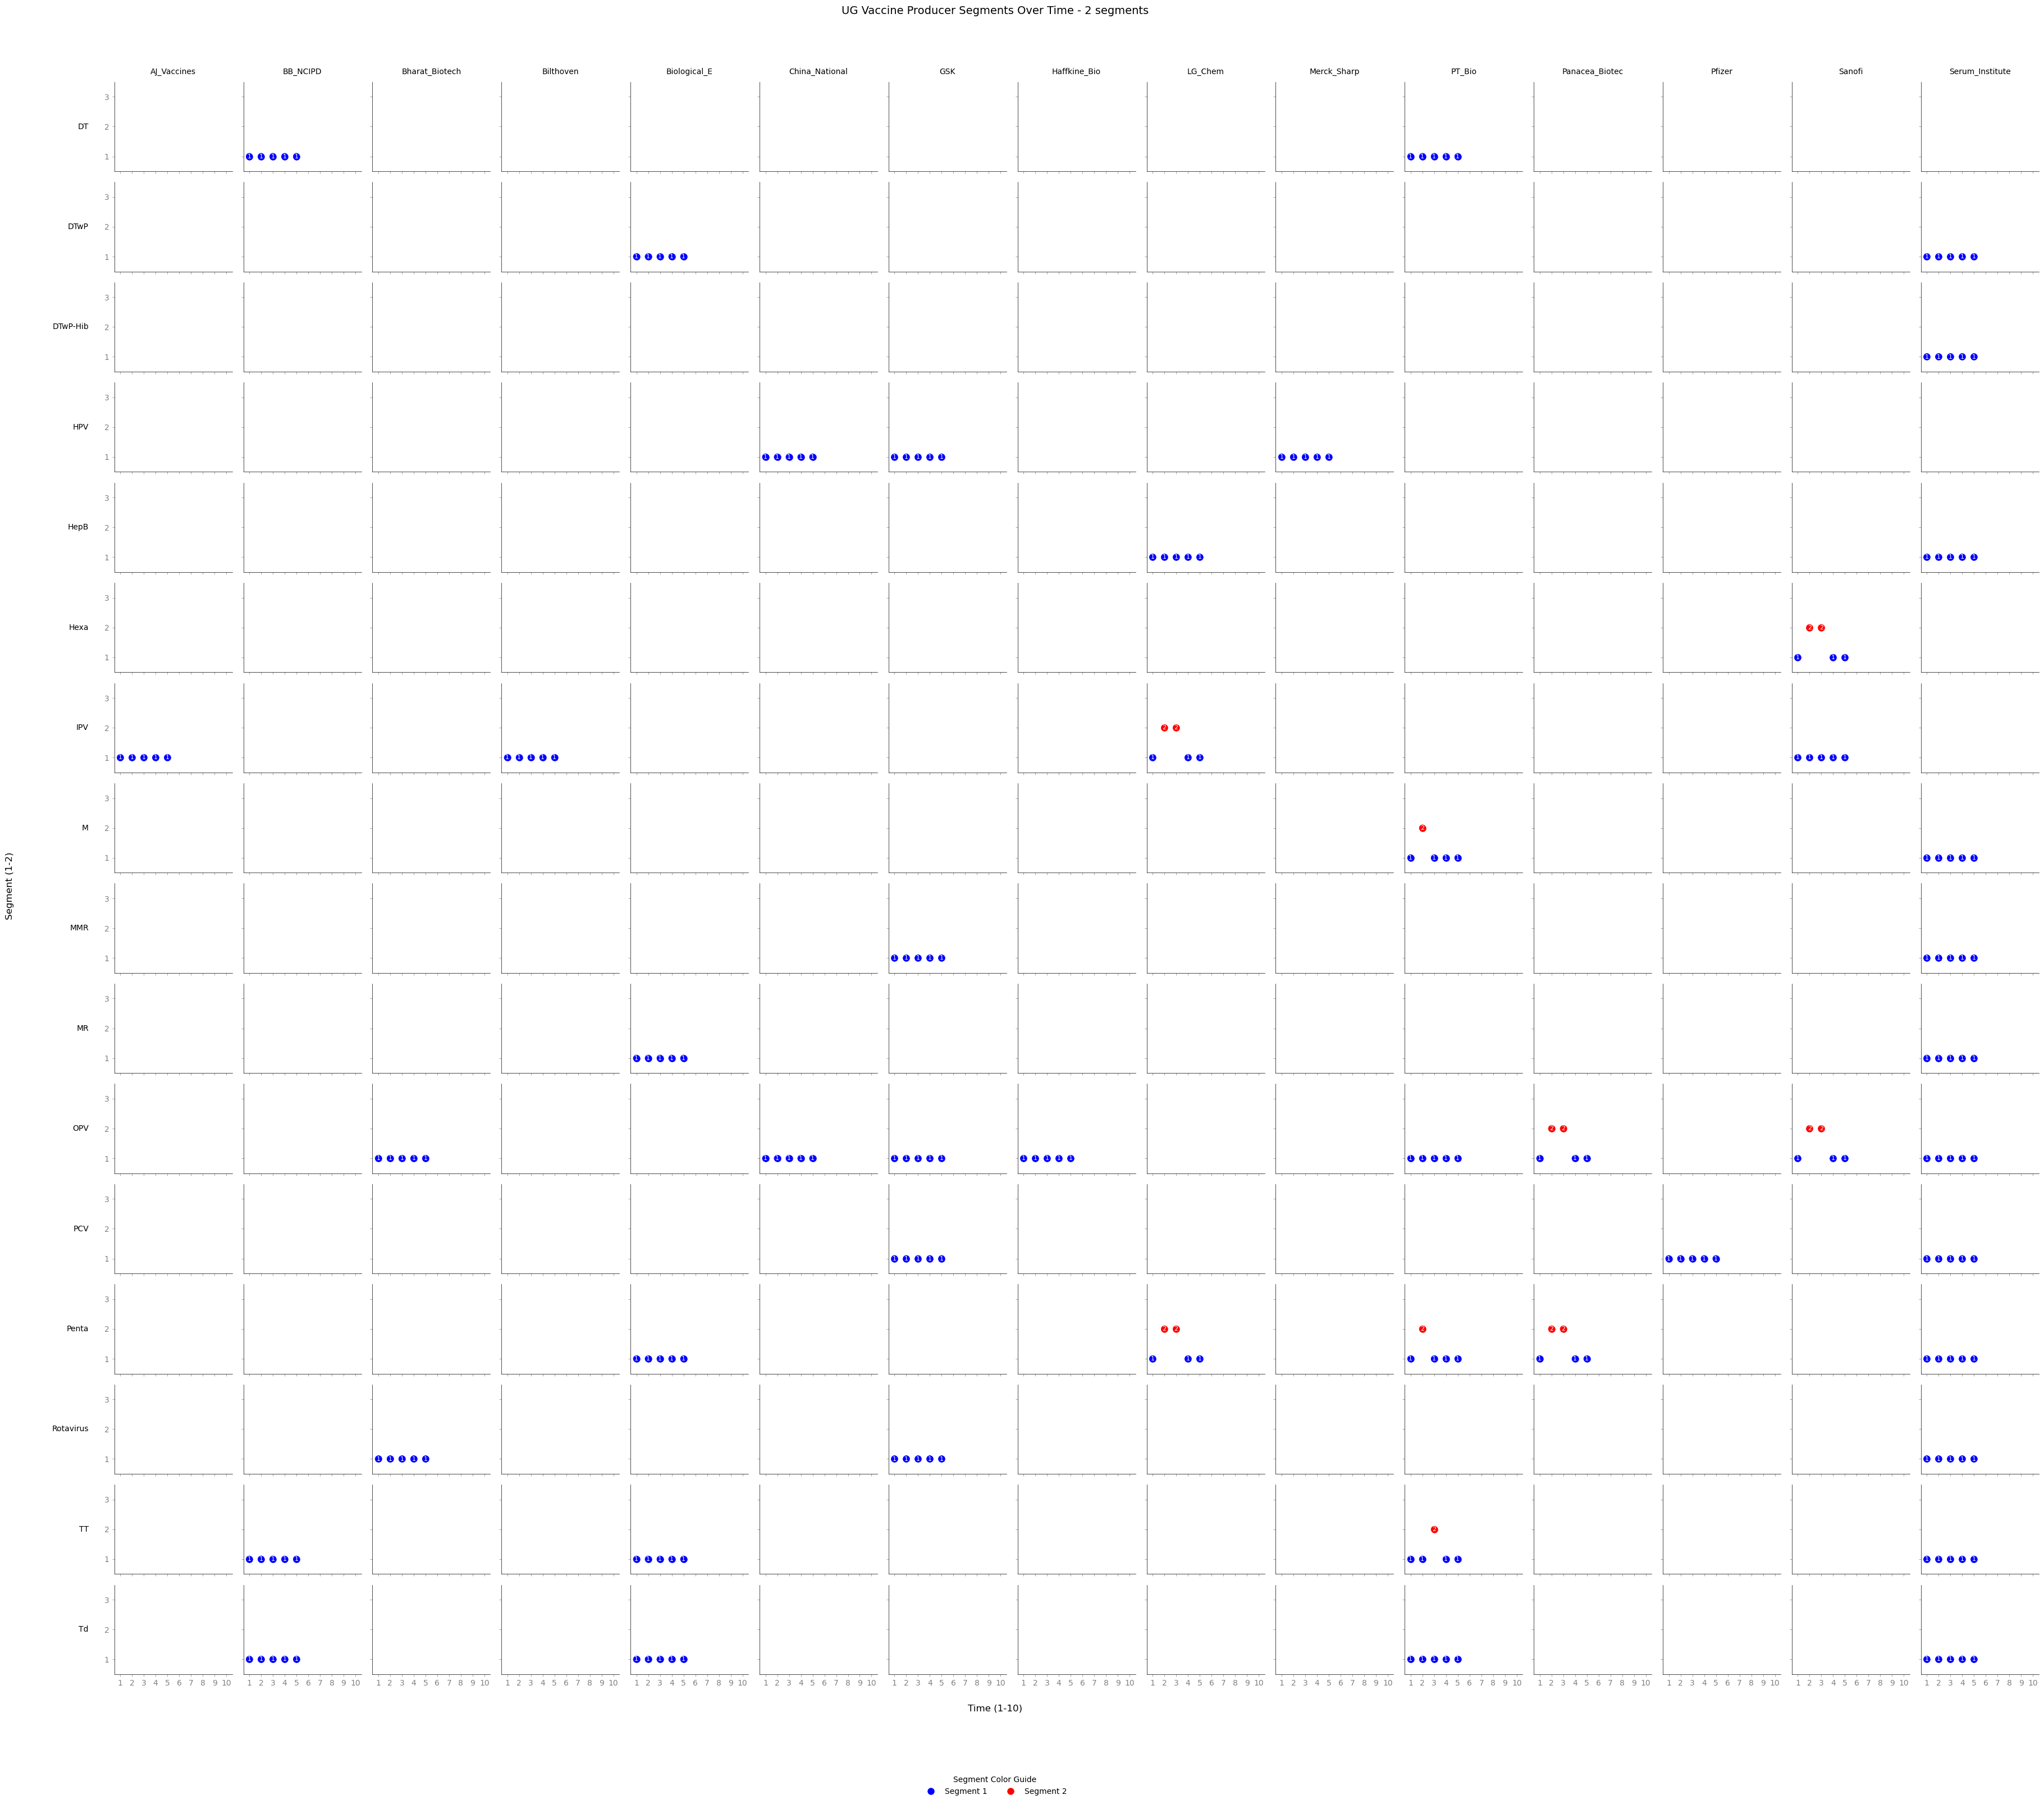

The Tufte-style graphic for trial 1 has been generated and saved as 'SINGLE_UG_2_segments_updated_10%_cap_inc_0%_supply_inc_vaccine_producer_segments_tufte_trial_1.png'.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import json # Import the json module to load JSON files


for trial in range(1, 2): # This loop will only run once for trial = 1
    # Load the JSON file
    # filename = f"results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand 3 segments no ROI/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    # filename = f"results/segment tests/4 segments/MVP_DE_results_T_5_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    filename = f"results/segment tests/2 segments new cons 8 UG/MVP_DE_results_T_5_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    print(f"Processing file: {filename}") # Added for debugging

    try:
        with open(filename) as json_file:
            data = json.load(json_file)
    except FileNotFoundError:
        print(f"Error: File not found at {filename}. Skipping this trial.")
        continue # Skip to the next iteration if the file doesn't exist

    # Call the function to extract information
    result = extract_segments_with_z_value_1(data)

    # Transform the dictionary into a list of dictionaries for DataFrame creation
    flat_data = []
    for vaccine, producers_data in result.items():
        clean_vaccine_name = vaccine.replace(" vaccine", "").strip()
        for producer, segments_list in producers_data.items():
            for entry in segments_list:
                flat_data.append({
                    "Vaccine": clean_vaccine_name,
                    "Producer": producer,
                    "Time": entry['Time'],
                    "Segment": entry['Segment']
                })

    df = pd.DataFrame(flat_data)

    # Get unique vaccines and producers for faceting
    # Sort for consistent plot order
    unique_vaccines = sorted(df['Vaccine'].unique())
    unique_producers = sorted(df['Producer'].unique())

    # Determine grid size for subplots
    num_rows = len(unique_vaccines)
    num_cols = len(unique_producers)

    # Create the figure and subplots for the current trial
    # Clear the current figure to ensure a fresh plot for each trial
    plt.close('all') # Close all existing figures to prevent overlap
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 2),
                             sharex='col', sharey='row', squeeze=False)

    # Define a color map for segments
    segment_colors = {
        1: 'blue',
        2: 'red'#,
        # 3: 'green',
        # 4: 'black'
    }

    # Iterate through each subplot to plot data
    for i, vaccine in enumerate(unique_vaccines):
        for j, producer in enumerate(unique_producers):
            ax = axes[i, j]
            subset_df = df[(df['Vaccine'] == vaccine) & (df['Producer'] == producer)]

            # Plot points and add segment labels
            for _, row in subset_df.iterrows():
                segment = row['Segment']
                color = segment_colors.get(segment, 'grey')
                ax.plot(row['Time'], row['Segment'], 'o', color=color, markersize=8, zorder=2)
                ax.text(row['Time'], row['Segment'], str(segment),
                        fontsize=8, ha='center', va='center', color='white',
                        bbox=dict(boxstyle="circle,pad=0.1", fc=color, ec="none", lw=0, alpha=0.8))

            # Set minimalist axes (Tufte style)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.5)
            ax.spines['bottom'].set_linewidth(0.5)

            # Remove ticks that don't align with segments/time
            ax.tick_params(axis='both', which='both', length=0)

            # Set x-axis ticks to be just the data points (1-10)
            ax.set_xticks(range(1, 11))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
            ax.tick_params(axis='x', direction='out', length=3, width=0.5, colors='gray')

            # Set y-axis ticks to be just the segments (1, 2, 3)
            ax.set_yticks([1, 2, 3])
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
            ax.tick_params(axis='y', direction='out', length=3, width=0.5, colors='gray')

            ax.set_ylim(0.5, 3.5)
            ax.set_xlim(0.5, 10.5)

            # Set titles for individual subplots
            if i == 0:
                ax.set_title(producer, fontsize=10, pad=10)
            if j == 0:
                ax.set_ylabel(vaccine, fontsize=10, rotation=0, ha='right', va='center', labelpad=20)

    # Adjust layout and add overall titles for the current trial's plot
    fig.supxlabel('Time (1-10)', fontsize=12, y=0.04)
    fig.supylabel('Segment (1-2)', fontsize=12, x=0.03)

    plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])
    plt.suptitle(f'UG Vaccine Producer Segments Over Time - 2 segments', fontsize=14, y=0.99) #Trial: {trial}

    # Create a custom legend for segment colors below the main chart
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Segment {s}',
                                  markerfacecolor=c, markersize=10)
                       for s, c in segment_colors.items()]
    fig.legend(handles=legend_elements, loc='lower center', ncol=len(segment_colors),
               title='Segment Color Guide', bbox_to_anchor=(0.5, -0.01),
               fancybox=False, shadow=False, frameon=False)

    # Save the chart with a unique filename for each trial
    output_filename = f'SINGLE_UG_2_segments_updated_10%_cap_inc_0%_supply_inc_vaccine_producer_segments_tufte_trial_{trial}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show() # Display the plot for the current trial

    print(f"The Tufte-style graphic for trial {trial} has been generated and saved as '{output_filename}'.")

In [5]:
filename = f"results/test new mccormick/mccormick/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
print(f"Processing file: {filename}") # Added for debugging

try:
    with open(filename) as json_file:
        data = json.load(json_file)
except FileNotFoundError:
    print(f"Error: File not found at {filename}. Skipping this trial.")

Processing file: results/test new mccormick/mccormick/MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json


In [23]:
import pandas as pd

rows = []

for (vaccine, producer_dict) in data['Q'].items():
    for (producer, t_dict) in producer_dict.items():
        for (t, tau_dict) in t_dict.items():
            for (tau, segment_dict) in tau_dict.items():
                for (segment, value) in segment_dict.items():
                    rows.append((vaccine, producer, t, tau, int(segment), value))

df = pd.DataFrame(rows, columns=["Vaccine", "Producer", "Start Year", "End Year", "Segment", "Value"])


In [26]:
filtered_df = df[df.Value != 0]

In [27]:
filtered_df.to_csv("filtered_Q_values.csv", index=False)